# K Means Clustering

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df=pd.read_csv('./resources/iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df=df[['petal_length','petal_width']]
df.head()

,petal_length,petal_width
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


Text(0, 0.5, 'petal width')

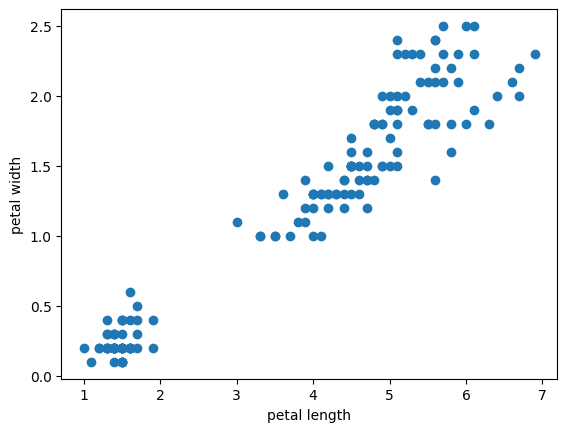

In [9]:
plt.scatter(df['petal_length'],df['petal_width'])
plt.xlabel('petal length')
plt.ylabel('petal width')

In [12]:
#preprocessing
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

scaler.fit(df[['petal_length']])
df['petal_length']=scaler.transform(df[['petal_length']])

scaler.fit(df[['petal_width']])
df['petal_width']=scaler.transform(df[['petal_width']])

Text(0, 0.5, 'petal width')

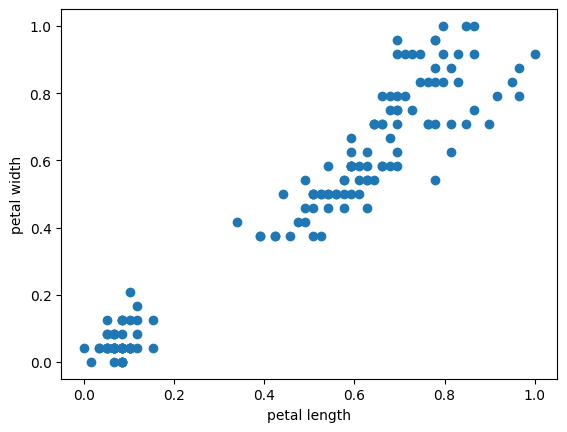

In [13]:
plt.scatter(df['petal_length'],df['petal_width'])
plt.xlabel('petal length')
plt.ylabel('petal width')

In [14]:
from sklearn.cluster import KMeans
km=KMeans()
y_predicted=km.fit_predict(df)
y_predicted

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 7, 1, 7, 1, 4, 1, 7, 4, 1, 7, 1, 7, 1,
       1, 7, 1, 7, 3, 7, 1, 7, 7, 1, 1, 3, 1, 4, 7, 4, 7, 1, 1, 1, 1, 7,
       7, 7, 7, 1, 7, 4, 7, 7, 7, 7, 4, 7, 2, 3, 2, 6, 2, 5, 1, 6, 6, 2,
       3, 3, 2, 3, 2, 2, 6, 5, 5, 1, 2, 3, 5, 3, 2, 6, 3, 3, 2, 6, 6, 5,
       2, 1, 6, 2, 2, 6, 3, 2, 2, 2, 3, 2, 2, 2, 3, 3, 2, 3], dtype=int32)

In [16]:
sse=[]
for k in range(1,11):
    km=KMeans(n_clusters=k)
    y_predicted=km.fit_predict(df)
    sse.append(km.inertia_)

Text(0, 0.5, 'sse')

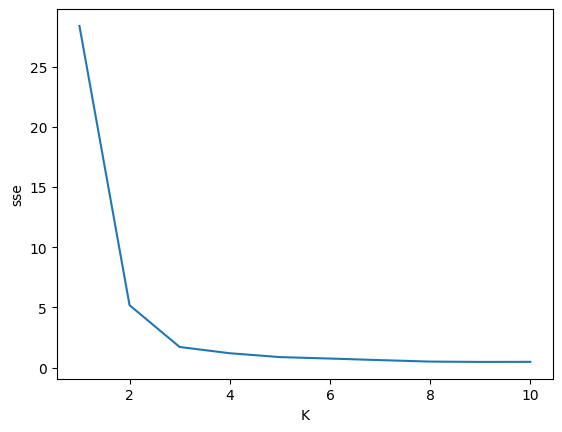

In [18]:
k_rng=range(1,11)
plt.plot(k_rng,sse)
plt.xlabel('K')
plt.ylabel('sse')

In [19]:
km=KMeans(n_clusters=3)
y_predicted=km.fit_predict(df)
y_predicted

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [20]:
df['cluster']=y_predicted
df.head()

,petal_length,petal_width,cluster
0,0.067797,0.041667,0
1,0.067797,0.041667,0
2,0.050847,0.041667,0
3,0.084746,0.041667,0
4,0.067797,0.041667,0


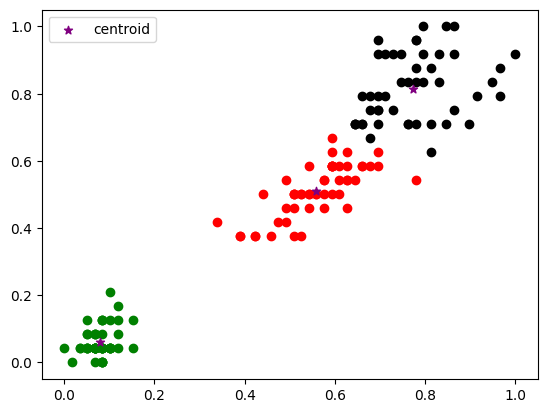

In [22]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1.petal_length,df1.petal_width,color='green')
plt.scatter(df2.petal_length,df2.petal_width,color='red')
plt.scatter(df3.petal_length,df3.petal_width,color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()